In [447]:
import numpy as np
import matplotlib.pyplot as plt

To transcribe this into a Jupyter Notebook format, I have converted the image text into Markdown cells and provided a template for the Python code requested in the prompts.

---

## 1. Trinomial Tree American Option Pricer

Write a python function to price an **American option** on a **trinomial tree** with the following input parameters:

* a. Spot price ($S$)
* b. Strike price ($K$)
* c. Time to maturity ($T$, in fraction of years)
* d. Risk free rate ($r$)
* e. Dividend yield ($d$)
* f. Stock return volatility ($\sigma$)
* g. Call or Put
* h. Choice of trinomial schema: CRR (Cox-Ross-Rubinstein) or JR (Jarrow-Rudd)
* i. Number of time steps ($N$)

---

Inspiration to modelling the trees for stock value and doing the backward industions is [here](https://github.com/AmineMahdioui/Option-Pricing-Interface/blob/main/option_models/Trinomials.py#L25).

In [449]:
def American_option_pricer(S, K, T, rf, dividend, stock_vol, call_or_put, trinomial_schema, N,
                           american_option=True, return_trees=False):
    time_step = T/N

    u = None
    d = None
    m = None
    drift = rf - dividend
    
    p_u = None
    p_d = None
    p_m = None

    # index 1 for call and index -1 for put
    call_or_put_index = None

    if trinomial_schema.upper() == "CRR" or trinomial_schema == "Cox-Ross-Rubinstein":
        u = np.exp(stock_vol*np.sqrt(3*time_step))
        d = 1/u
        m = 1

        p_u = (1/6) + ((drift - ((stock_vol**2)/2))*np.sqrt(time_step)/(2*stock_vol*np.sqrt(3)))
        p_d = (1/6) - ((drift - ((stock_vol**2)/2))*np.sqrt(time_step)/(2*stock_vol*np.sqrt(3)))
        p_m = 2/3

    elif trinomial_schema.upper() == "JR" or trinomial_schema == "Jarrow-Rudd":
        u = np.exp((drift-((stock_vol**2)/2))*time_step + stock_vol*np.sqrt(3*time_step))
        d = np.exp((drift-((stock_vol**2)/2))*time_step - stock_vol*np.sqrt(3*time_step))
        m = np.exp((drift-((stock_vol**2)/2))*time_step)

        p_u = 1/6
        p_m = 2/3
        p_d = 1/6

    else:
        raise ValueError('The Schema you are trying to find is invalid please try CRR or JR')

    
    #Process the terminal stock price
    stock_val_matrix = np.zeros((N+1,2*N+1))
    option_val_matrix = np.zeros((N+1,2*N+1))

    stock_val_matrix[0,0] = S
    for i in range(N+1):
        for j in range(2*N +1):
            stock_val_matrix[i,j] = S * u**(i-j if (i>=j) else 0) * d**((j-i) if (i<j) else 0)

    
    if call_or_put.lower() == "call":
        call_or_put_index = 1
    elif call_or_put.lower() == "put":
        call_or_put_index = -1

    else:
        raise ValueError("Please put in a proper value like Call or Put")
        
    # Backward recursion for option price
    for j in range(N+1):
        option_val_matrix[N,j] = max(0, call_or_put_index*(stock_val_matrix[N, j]-K))
    for i in range(N-1,-1,-1):
        for j in range(2*i+1):
            option_val_matrix[i,j] = (p_u*option_val_matrix[i+1,j]+p_m*option_val_matrix[i+1,j+1]+p_d*option_val_matrix[i+1,j+2])/np.exp(-rf*time_step)
            if american_option == True:
                option_val_matrix[i,j] = max(option_val_matrix[i,j],call_or_put_index*(stock_val_matrix[i,j]-K))

    # if return_trees:
    #     print(f"""
    #     stock_tree": 
    #     {stock_val_matrix},
        
    #     option_tree:
    #     {option_val_matrix}
    #     """)

    # print(f"""
    # Option value is {option_val_matrix[0,0]}
    # """)
    return option_val_matrix[0,0]

___
## 2. Analysis and Exercises

Carry out the following using your python pricer, and write a short paragraph to describe your observation in each of the exercises below.

### a. Early Exercise Boundary (CRR)

On a **CRR trinomial tree**, price the following **American call option** and **plot the early exercise boundary** as a function of time.

* i. $S = 100$
* ii. $K = 80$
* iii. $T = 1$
* iv. $r = 0$
* v. $d = 0.2$
* vi. $Vol = 0.3$
* vii. Number of time steps = $250$

In [452]:
if __name__ == "__main__":
    S = 100
    K = 80
    T = 1
    rf = 0.
    dividend = 0.2
    stock_vol = 0.3
    call_or_put = "Call"
    trinomial_schema = "CRR"
    N = 250
    american_option = True
    
    price = American_option_pricer(S, K, T, rf, dividend, stock_vol, call_or_put, trinomial_schema, N, american_option,return_trees=True)
    print(f"American {call_or_put} Option Price for {trinomial_schema} model is: ${price:.2f}")

American Call Option Price for CRR model is: $20.00


In [453]:
def American_option_boundary_condition_finder(S, K, T, rf, dividend, stock_vol, call_or_put, trinomial_schema, N,
                           american_option=True):
    time_step = T/N

    u = None
    d = None
    m = None
    drift = rf - dividend
    
    p_u = None
    p_d = None
    p_m = None

    # index 1 for call and index -1 for put
    call_or_put_index = None

    boundary_condition_dictionary = {}

    if trinomial_schema.upper() == "CRR" or trinomial_schema == "Cox-Ross-Rubinstein":
        u = np.exp(stock_vol*np.sqrt(3*time_step))
        d = 1/u
        m = 1

        p_u = (1/6) + ((drift - ((stock_vol**2)/2))*np.sqrt(time_step)/(2*stock_vol*np.sqrt(3)))
        p_d = (1/6) - ((drift - ((stock_vol**2)/2))*np.sqrt(time_step)/(2*stock_vol*np.sqrt(3)))
        p_m = 2/3

    elif trinomial_schema.upper() == "JR" or trinomial_schema == "Jarrow-Rudd":
        u = np.exp((drift-((stock_vol**2)/2))*time_step + stock_vol*np.sqrt(3*time_step))
        d = np.exp((drift-((stock_vol**2)/2))*time_step - stock_vol*np.sqrt(3*time_step))
        m = np.exp((drift-((stock_vol**2)/2))*time_step)

        p_u = 1/6
        p_m = 2/3
        p_d = 1/6

    else:
        raise ValueError('The Schema you are trying to find is invalid please try CRR or JR')

    
    #Process the terminal stock price
    stock_val_matrix = np.zeros((N+1,2*N+1))
    option_val_matrix = np.zeros((N+1,2*N+1))

    stock_val_matrix[0,0] = S
    for i in range(N+1):
        for j in range(2*N +1):
            stock_val_matrix[i,j] = S * u**(i-j if (i>=j) else 0) * d**((j-i) if (i<j) else 0)

    
    if call_or_put.lower() == "call":
        call_or_put_index = 1
    elif call_or_put.lower() == "put":
        call_or_put_index = -1

    else:
        raise ValueError("Please put in a proper value like Call or Put")
        
    # Backward recursion for option price
    for j in range(N+1):
        option_val_matrix[N,j] = max(0, call_or_put_index*(stock_val_matrix[N, j]-K))
    for i in range(N-1,-1,-1):
        list_of_potential_bondary_condition_i = []
        
        for j in range(2*i+1):
            option_val_matrix[i,j] = (p_u*option_val_matrix[i+1,j]+p_m*option_val_matrix[i+1,j+1]+p_d*option_val_matrix[i+1,j+2])/np.exp(-rf*time_step)
            if american_option == True:
                option_val_matrix[i,j] = max(option_val_matrix[i,j],call_or_put_index*(stock_val_matrix[i,j]-K))
                if call_or_put_index*(stock_val_matrix[i,j]-K) >= option_val_matrix[i,j]:
                    list_of_potential_bondary_condition_i.append(call_or_put_index*(stock_val_matrix[i,j]-K))

        boundary_condition_dictionary[str(i)] = min(list_of_potential_bondary_condition_i)
        


    return boundary_condition_dictionary

In [454]:
S = 100
K = 80
T = 1
rf = 0.
dividend = 0.2
stock_vol = 0.3
call_or_put = "Call"
trinomial_schema = "CRR"
N = 250
american_option = True
    
boundary_condition = American_option_boundary_condition_finder(S, K, T, rf, dividend, stock_vol, call_or_put, trinomial_schema, N)
# boundary_condition

In [455]:
time = [int(i)/(N/T) for i in boundary_condition.keys()]
time[:5]

[0.996, 0.992, 0.988, 0.984, 0.98]

In [456]:
prices = [i for i in boundary_condition.values()]
prices[:5]

[2.104273319976045,
 4.847321078018496,
 4.847321078018496,
 4.847321078018496,
 4.847321078018496]

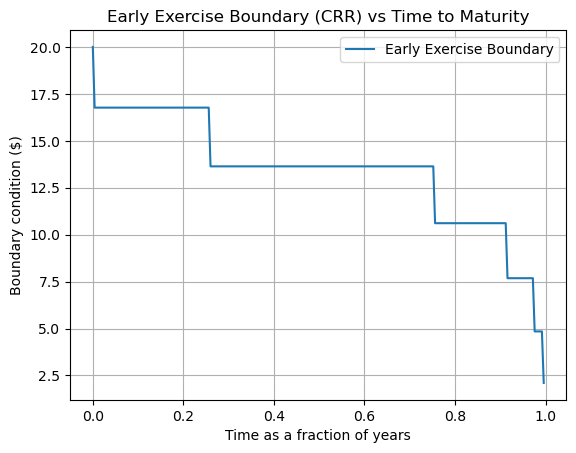

In [457]:
plt.plot(time, prices, label="Early Exercise Boundary")
plt.grid(True)
plt.xlabel("Time as a fraction of years")
plt.ylabel("Boundary condition ($)")
plt.title(f"Early Exercise Boundary ({trinomial_schema}) vs Time to Maturity")
plt.legend()
plt.show()

As we near maturity, the critical stock prices needed to trigger early exercise decreases. Early in the option life we would probably need a high stock price to exercise early due to time value where we want to wait and see if the price goes up. 

However, as we near maturity, time values moves towards zero but in our case considering the dividend yield of 20% is kind of high, the "cost" of holding option becomes larger than remaining time value so we don't really hit zero. As such, we kind of want to exercise at a lower underlying price to capture inrinsic value before a dividend-driven price drop.

### b. American Put Pricing (JR)

Using a **JR trinomial tree**, price the following **American put option**:

* i. $S = 100$
* ii. $K = 120$
* iii. $T = 1$
* iv. $R = 0.04$
* v. $D = 0$
* vi. $Vol = 0.3$
* vii. Number of time steps = $250$

In [460]:
S = 100
K = 120
T = 1
rf = 0.04
dividend = 0
stock_vol = 0.3
call_or_put = "Put"
trinomial_schema = "JR"
N = 250
american_option = True
    
price = American_option_pricer(S, K, T, rf, dividend, stock_vol, call_or_put, trinomial_schema, N, american_option,return_trees=True)
print(f"American {call_or_put} Option Price for {trinomial_schema} model is: ${price:.2f}")

American Put Option Price for JR model is: $23.79


### c. Sensitivity Analysis (Greeks & Parameters)

Continue with the above put option and perform the following visualizations:

* **i. Price vs Spot:** Plot option price vs changing spot price while holding other parameters constant: $S \in [50, 160]$
* **ii. Price vs Time:** Plot option price vs changing time to maturity while holding other parameters constant: $T \in [0.25, 2]$
* **iii. Price vs Volatility:** Plot option price vs changing volatility while holding other parameters constant: $vol \in [0.15, 1.5]$

* **i. Price vs Spot:** Plot option price vs changing spot price while holding other parameters constant: $S \in [50, 160]$


In [463]:
list_of_stock_prices = [i for i in range(50,161,1)]
list_of_stock_prices[:2]

[50, 51]

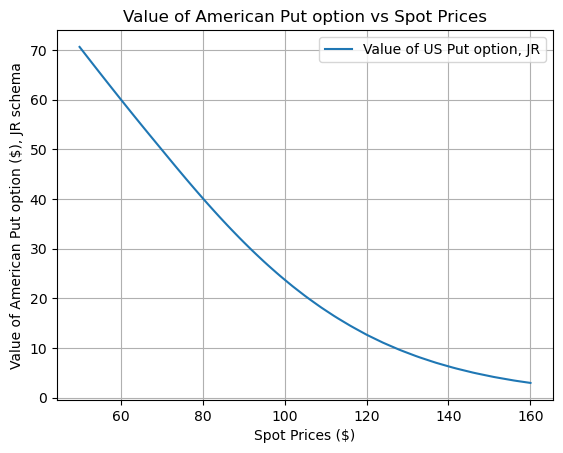

In [464]:
S = 100
K = 120
T = 1
rf = 0.04
dividend = 0
stock_vol = 0.3
call_or_put = "Put"
trinomial_schema = "JR"
N = 250
american_option = True
    
list_of_prices = [American_option_pricer(stock_price, K, T, rf, dividend, stock_vol, call_or_put, trinomial_schema, N, american_option,return_trees=True) for stock_price in list_of_stock_prices]

plt.plot(list_of_stock_prices, list_of_prices, label=f"Value of US {call_or_put} option, {trinomial_schema}")
plt.grid(True)
plt.xlabel("Spot Prices ($)")
plt.ylabel(f"Value of American {call_or_put} option ($), {trinomial_schema} schema")
plt.title(f"Value of American {call_or_put} option vs Spot Prices")
plt.legend()
plt.show()

**Observation**: Assuming ceteris paribus, as the spot price increases, the intrinsic value of the American put option decreases.

* **ii. Price vs Time:** Plot option price vs changing time to maturity while holding other parameters constant: $T \in [0.25, 2]$


In [466]:
list_of_times = [i/100 for i in range(25,201,1)]
list_of_times[:5]

[0.25, 0.26, 0.27, 0.28, 0.29]

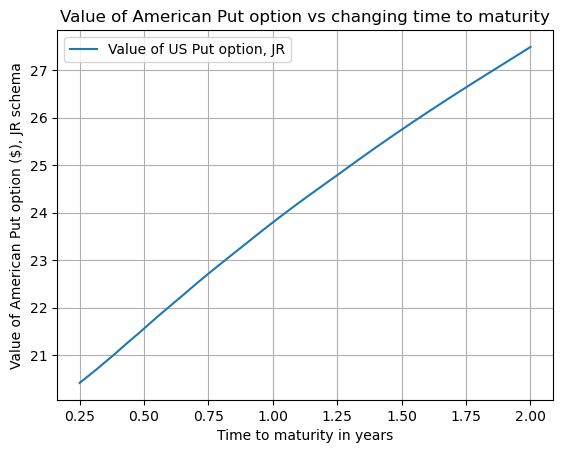

In [467]:
S = 100
K = 120
T = 1
rf = 0.04
dividend = 0
stock_vol = 0.3
call_or_put = "Put"
trinomial_schema = "JR"
N = 250
american_option = True
    
list_of_prices = [American_option_pricer(S, K, time, rf, dividend, stock_vol, call_or_put, trinomial_schema, N, american_option,return_trees=True) for time in list_of_times]

plt.plot(list_of_times, list_of_prices, label=f"Value of US {call_or_put} option, {trinomial_schema}")
plt.grid(True)
plt.xlabel("Time to maturity in years")
plt.ylabel(f"Value of American {call_or_put} option ($), {trinomial_schema} schema")
plt.title(f"Value of American {call_or_put} option vs changing time to maturity")
plt.legend()
plt.show()

**Observation**: Assuming ceteris paribus, as the time to maturity of the put option increases, the intrinsic value of the American put option increases.

* **iii. Price vs Volatility:** Plot option price vs changing volatility while holding other parameters constant: $vol \in [0.15, 1.5]$

In [478]:
list_of_volatility = [i/100 for i in range(15,151,1)]
list_of_volatility[:5]

[0.15, 0.16, 0.17, 0.18, 0.19]

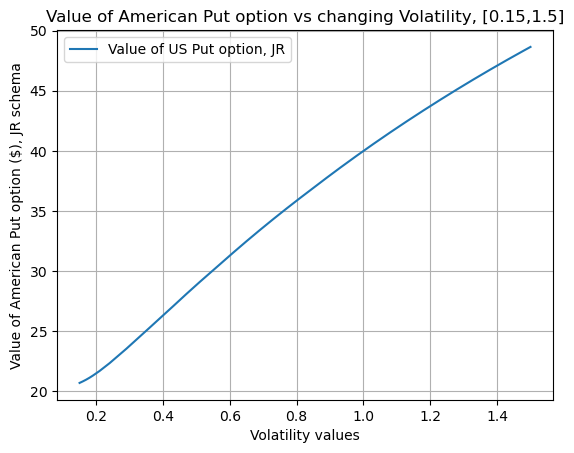

In [485]:
S = 100
K = 120
T = 1
rf = 0.04
dividend = 0
stock_vol = 0.3
call_or_put = "Put"
trinomial_schema = "JR"
N = 250
american_option = True
    
list_of_prices = [American_option_pricer(S, K, T, rf, dividend, volatility, call_or_put, trinomial_schema, N, american_option,return_trees=True) for volatility in list_of_volatility]

plt.plot(list_of_volatility, list_of_prices, label=f"Value of US {call_or_put} option, {trinomial_schema}")
plt.grid(True)
plt.xlabel("Volatility values")
plt.ylabel(f"Value of American {call_or_put} option ($), {trinomial_schema} schema")
plt.title(f"Value of American {call_or_put} option vs changing Volatility, [0.15,1.5]")
plt.legend()
plt.show()

**Observation**: Assuming ceteris paribus, as the volatility of the put option increases, the intrinsic value of the American put option increases.